In [8]:
import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [2]:
# MNIST normalisation
transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(len(mnist_train) * 0.8)
validation_size = len(mnist_train) - train_size
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [train_size, validation_size])

batch_size = 128
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=6)

In [3]:
test_images = []
test_labels = []

for batch_idx, (data, target) in enumerate(test_loader):
    data = Variable(data)
    test_images.append(data)
    test_labels.append(target)

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)
test_images = test_images.squeeze(1)

In [4]:
save_path = os.getenv("HOME") + '/ae_models/'

In [5]:
def train_sae(save_path):
    sae_model = NonLinearAutoencoder(n_input=784, n_hidden_ls=[512, 128, 16], n_layers=3)
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)

    sae_train_loss, sae_validation_loss = train_vali_all_epochs(
        sae_model, 
        train_loader, 
        validation_loader, 
        sae_optimizer, 
        n_epochs=30, 
        device=torch.device('cuda'), 
        save_path=save_path+'/'
        )
    
    return sae_model, sae_train_loss, sae_validation_loss

In [6]:
def train_dae(save_path):
    dae_model = NonLinearAutoencoder(n_input=784, n_hidden_ls=[512, 128, 32], n_layers=3)
    dae_optimizer = torch.optim.SGD(dae_model.parameters(), lr=0.1, momentum=0.9)

    size_ls = [4] * 14 + [8] * 14 + [16] * 20 + [32] * 32

    manner = 'gaussian'

    dae_train_loss, dae_validation_loss = nl_dev_train_vali_all_epochs(
        dae_model, 
        size_ls,
        manner,
        train_loader,
        validation_loader, 
        dae_optimizer, 
        n_epochs=80,
        device=torch.device('cpu'), 
        save_path=save_path+'/'
        )
    
    return dae_model, dae_train_loss, dae_validation_loss

In [7]:
dae_model = train_dae(save_path)

Directory created: /home/david/ae_models//
[ 4  4  4  4  4  4  4  4  4  4  4  4  4  4  8  8  8  8  8  8  8  8  8  8
  8  8  8  8 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16
 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32 32
 32 32 32 32 32 32 32 32]
4


Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.005104: 100%|██████████| 375/375 [00:05<00:00, 65.33it/s]


====> Epoch: 0 Average loss: 0.6958


/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:493: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)


====> Test set loss: 0.6519
Weights saved.
4


...

====> Epoch: 78 Average loss: 0.1382


====> Test set loss: 0.1455
Weights saved.
32


Train Epoch: 79 [47872/48000 (100%)]	Loss: 0.001121: 100%|██████████| 375/375 [00:04<00:00, 89.22it/s]

====> Epoch: 79 Average loss: 0.1374


====> Test set loss: 0.1442
Weights saved.
All train losses saved.


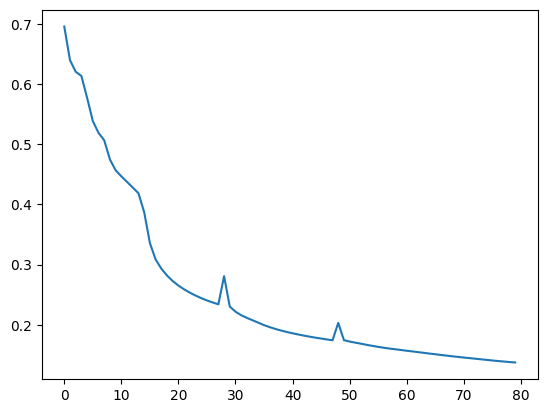

In [9]:
plt.plot(dae_model[1], label='train')

In [10]:
size_ls = [4] * 14 + [8] * 14 + [16] * 20 + [32] * 32

In [11]:
len(size_ls)

80

In [12]:
def load_model(model_path, model_type, epoch, size_ls=None):
    n_input = 28*28
    n_layers = 3
    sae_n_hidden_ls = [512, 128, 16]

    if size_ls is None:
        size_ls = [4] * 14 + [8] * 14 + [16] * 20 + [32] * 32
        
    dae_n_hidden_ls = [512, 128, size_ls[epoch]]
    
    if model_type == 'sae' or model_type == 'SAE':
        model = NonLinearAutoencoder(n_input, sae_n_hidden_ls, n_layers)
    else:
        model = NonLinearAutoencoder(n_input, dae_n_hidden_ls, n_layers)
    weights = torch.load(f"{model_path}/model_weights_epoch{epoch}.pth")
    model.load_state_dict(weights)
    return model

In [13]:
model_type = 'dae'
all_angles = []

for model in range(1):
    latent_matrices = []
    for epoch in tqdm(range(80), leave=True):
        latent_matrix = []
        model_path = save_path
        ae = load_model(model_path, model_type=model_type, epoch=epoch)
        
        for image in test_images:
            image = torch.tensor(image, dtype=torch.float32).reshape(-1)

            with torch.no_grad():
                encoded, _ = ae(image)
                latent_matrix.append(encoded.detach().numpy())
        
        latent_matrix = np.stack(latent_matrix)

        pca = PCA(n_components=size_ls[epoch])
        pca.fit(latent_matrix)

        pca_components = np.pad(pca.components_, (0, 32 - pca.components_.shape[0]), 'constant')
        latent_matrices.append(pca_components)

    angles_per_model = []
    for i in range(32):
        angles_per_pc = []
        for j in range(79):
            cosine_angle = cosine_angle_between_pcs(latent_matrices[j][i], latent_matrices[j+1][i])
            angles_per_pc.append(cosine_angle)
        angles_per_model.append(angles_per_pc)
    all_angles.append(angles_per_model)

  0%|          | 0/80 [00:00<?, ?it/s]/tmp/ipykernel_35135/1318585150.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(f"{model_path}/model_weights_

In [14]:
np.array(all_angles).shape

(1, 32, 79)

In [15]:
angle_matrix = np.array(all_angles).squeeze()

In [16]:
highlighted_non_computable_angles = angle_matrix.copy()

for i in range(highlighted_non_computable_angles.shape[0]):
    for j in range(highlighted_non_computable_angles.shape[1] - 1):
        if np.isnan(highlighted_non_computable_angles[i, j]) and not np.isnan(highlighted_non_computable_angles[i, j + 1]):
            highlighted_non_computable_angles[i, j] = 100

mask = highlighted_non_computable_angles == 100
non_computable_cells = np.where(mask, 1, np.nan)

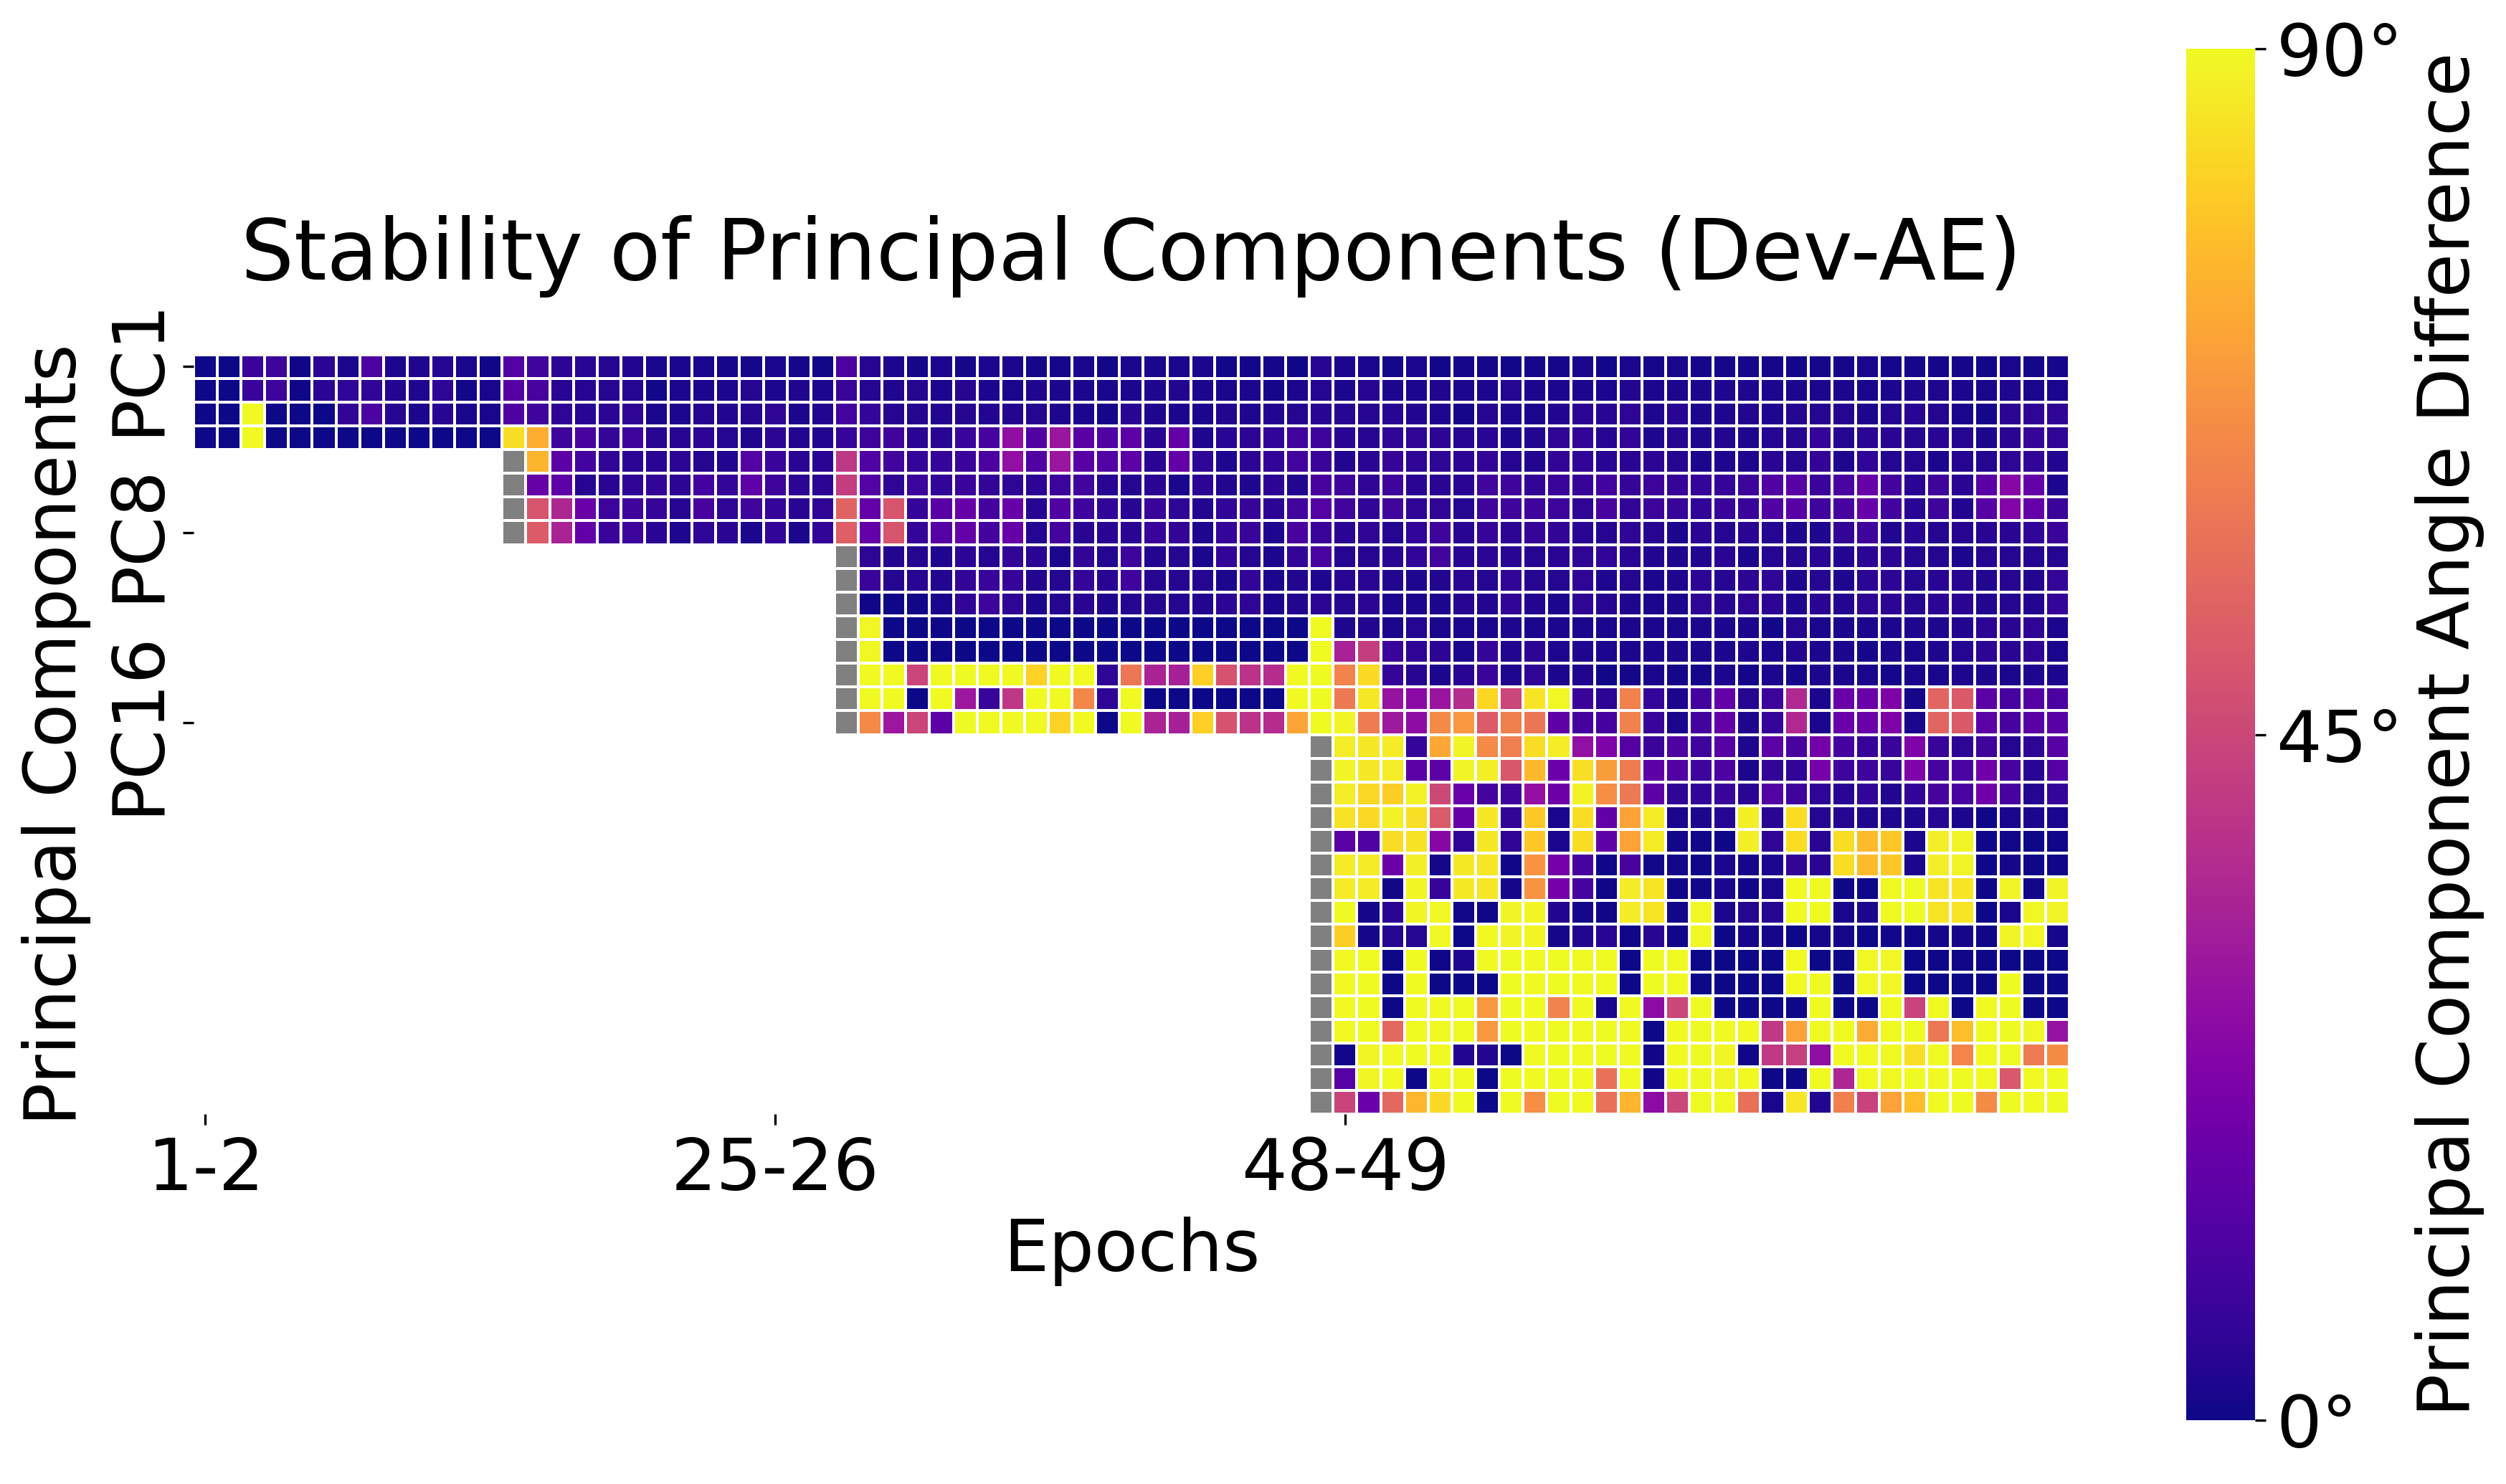

In [17]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

heatmap = sns.heatmap(
    angle_matrix,
    cmap="plasma",
    vmin=0,
    vmax=90,
    cbar_kws={"label": "Angle between PCs"},
    linewidths=0.5,
    square=True,
)

cmap_grey = ListedColormap(['grey'])
sns.heatmap(
    non_computable_cells[:, :],
    cmap=cmap_grey,
    cbar=False,
    alpha=1,
    linewidths=0.5,
    square=True,
)

cbar = heatmap.collections[0].colorbar
cbar.set_ticks([0, 45, 90])
cbar.set_ticklabels(["0°", "45°", "90°"], fontsize=24)
cbar.set_label("Principal Component Angle Difference", fontsize=24)
cbar.minorticks_off()

ax.set_xticks([0.5, 24.5, 48.5])
ax.set_xticklabels(["1-2", "25-26", "48-49"], fontsize=24, rotation=0)

ax.set_yticks([0.5, 7.5, 15.5])
ax.set_yticklabels(["PC1", "PC8", "PC16"], fontsize=24, rotation=90)

ax.set_title("Stability of Principal Components (Dev-AE)", fontsize=28, pad=25)
ax.set_xlabel("Epochs", fontsize=24)
ax.set_ylabel("Principal Components", fontsize=24)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.autograd import Variable

import act_max_util as amu

from solver import *

%load_ext autoreload
%autoreload 2

In [20]:
steps = 100               # perform 100 iterations
unit = 0                  # flamingo class of Imagenet
alpha = torch.tensor(100) # learning rate (step size)
verbose = False           # print activation every step
L2_Decay = True           # enable L2 decay regularizer
Gaussian_Blur = False     # enable Gaussian regularizer
Norm_Crop = False         # enable norm regularizer
Contrib_Crop = False      # enable contribution regularizer

In [21]:
data = torch.randn(28, 28)
data = data.unsqueeze(0)
input = data.view(data.size(0), -1)
input.requires_grad_(True)

dae = load_model(save_path, 'dae', 79)

layer_name = 'bottle_neck'
dae_activation_dictionary = {}

dae.encoder.activation_3.register_forward_hook(amu.layer_hook(dae_activation_dictionary, layer_name))

dae_rf_ls = []
for i in range(32):
    output = amu.act_max(network=dae,
                    input=input,
                    layer_activation=dae_activation_dictionary,
                    layer_name=layer_name,
                    unit=i,
                    steps=steps,
                    alpha=alpha,
                    verbose=verbose,
                    L2_Decay=L2_Decay,
                    Gaussian_Blur=Gaussian_Blur,
                    Norm_Crop=Norm_Crop,
                    Contrib_Crop=Contrib_Crop,
                    )
    dae_rf_ls.append(output.detach().numpy())

dae_rf_ls = np.array(dae_rf_ls).squeeze()

/tmp/ipykernel_35135/1318585150.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(f"{model_path}/model_weights_epoch{epoch}.pth")


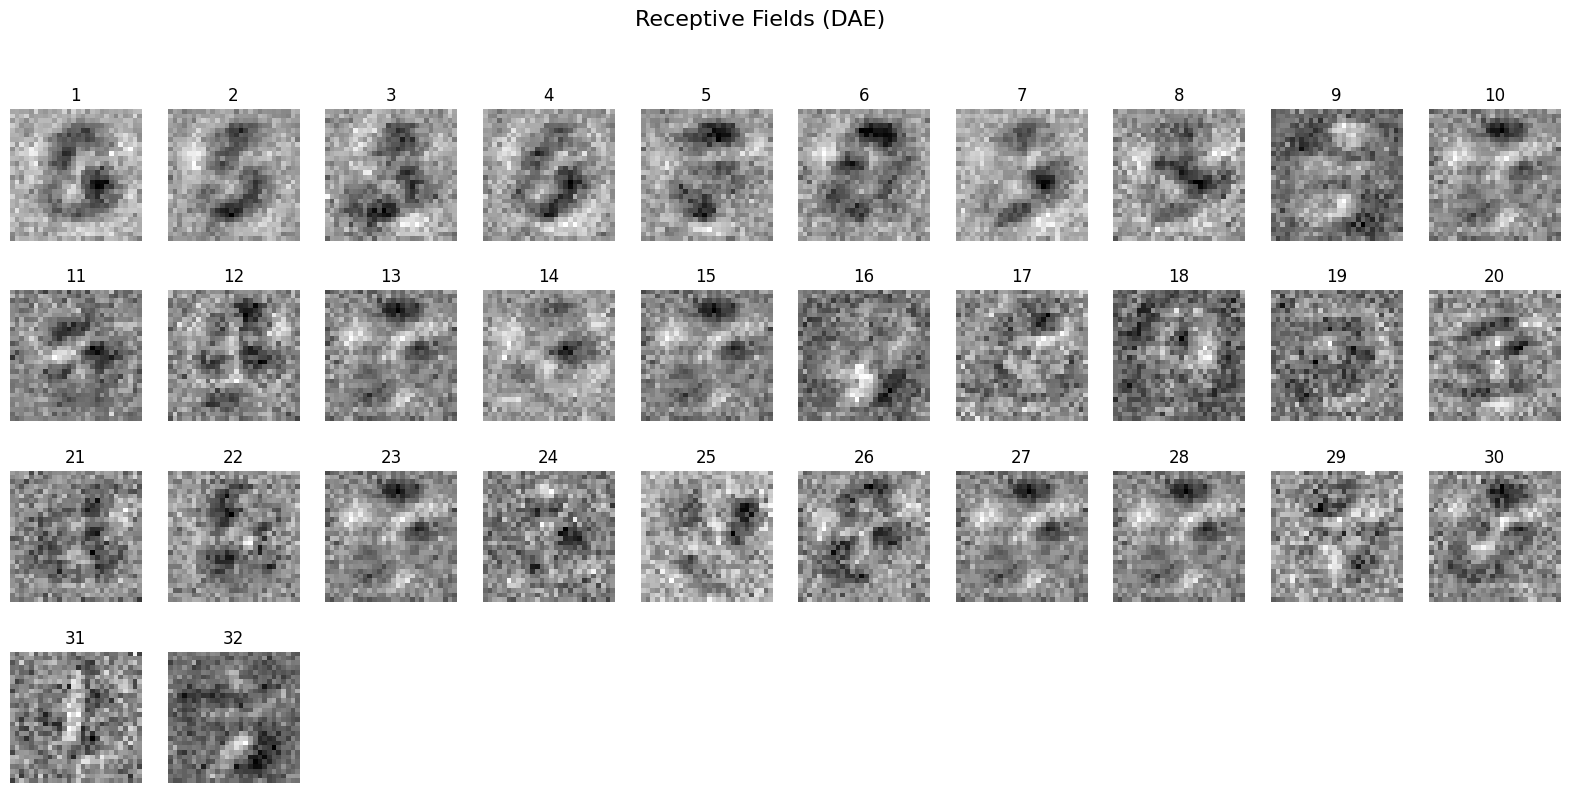

In [22]:
fig = plt.figure(figsize=(20,9))
fig.suptitle("Receptive Fields (DAE)", fontsize=16)
for i in range(32):
    plt.subplot(4,10,i+1)
    plt.title(str(i+1))
    plt.axis('off')
    plt.imshow(dae_rf_ls[i].reshape(28,28),cmap='gray')

In [23]:
# For all different models
dae_rf_matrices = []

for iteration in tqdm(range(1)):
    # For all different epochs
    dae_rf_matrix = []
    
    for epoch in range(80):
        data = torch.randn(28, 28)
        data = data.unsqueeze(0)
        input = data.view(data.size(0), -1)
        input.requires_grad_(True)

        dae = load_model(save_path, 'dae', epoch)
        
        layer_name = 'bottle_neck'
        dae_activation_dictionary = {}

        dae.encoder.encoder_3.register_forward_hook(amu.layer_hook(dae_activation_dictionary, layer_name))

        dae_rf_ls = []
        for i in range(size_ls[epoch]):
            output = amu.act_max(network=dae,
                            input=input,
                            layer_activation=dae_activation_dictionary,
                            layer_name=layer_name,
                            unit=i,
                            steps=steps,
                            alpha=alpha,
                            verbose=verbose,
                            L2_Decay=L2_Decay,
                            Gaussian_Blur=Gaussian_Blur,
                            Norm_Crop=Norm_Crop,
                            Contrib_Crop=Contrib_Crop,
                            )
            dae_rf_ls.append(output.detach().numpy())
        dae_rf_ls = np.array(dae_rf_ls).squeeze()

        dae_rf_matrix.append(dae_rf_ls)

    dae_rf_matrices.append(dae_rf_matrix)

  0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_35135/1318585150.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(f"{model_path}/model_weights_e

In [24]:
def cosine_angle_between_pcs(pc_a, pc_b):
    numerator = np.dot(pc_a, pc_b)
    denominator = np.linalg.norm(pc_a) * np.linalg.norm(pc_b)

    cos_value = numerator / denominator

    angle = np.arccos(cos_value) * 180 / np.pi

    if angle > 90:
        angle = 180 - angle
    
    return angle

In [25]:
def pad_matrices(model_ls, target_dim=32):
    padded_data = []
    for epoch_ls in model_ls:
        padded_epoch_ls = []
        for neuron_ls in epoch_ls:
            padding_array = np.zeros((target_dim - len(neuron_ls), 784))
            padded_neuron_ls = np.vstack([neuron_ls, padding_array])
            padded_epoch_ls.append(padded_neuron_ls)
        padded_data.append(padded_epoch_ls)
    return np.array(padded_data)

In [28]:
dae_rf_matrices = pad_matrices(dae_rf_matrices)
dae_rf_matrices.shape

(1, 80, 32, 784)

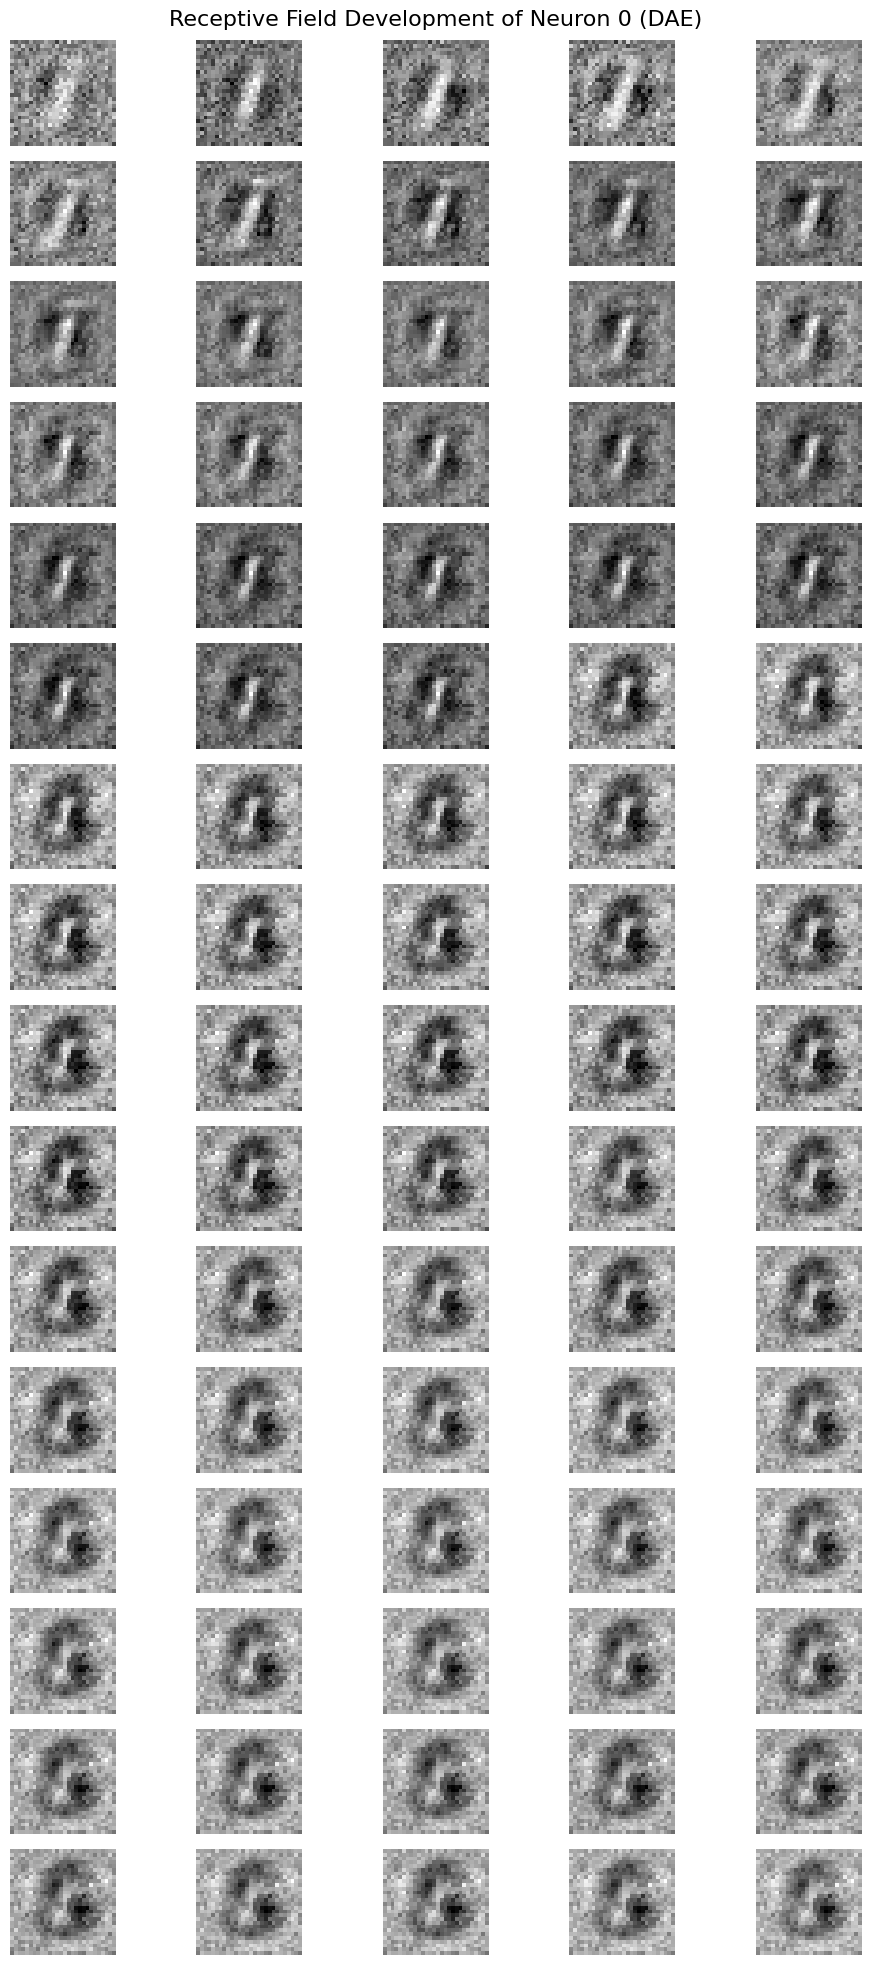

In [30]:
fig, axes = plt.subplots(16, 5, figsize=(10, 20))
axes = axes.ravel()

for i in range(80):
    axes[i].imshow(dae_rf_matrices[0][i][0].reshape(28, 28), cmap='binary_r')
    axes[i].axis('off')

fig.suptitle("Receptive Field Development of Neuron 0 (DAE)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [31]:
num_models = 1
num_epochs = 80
num_neurons = 32

dae_angles_matrix = np.zeros((num_models, num_neurons, num_epochs-1))

for model in range(num_models):
    for epoch in range(num_epochs-1):
        for neuron in range(num_neurons):
            angle = cosine_angle_between_pcs(dae_rf_matrices[model][epoch][neuron], dae_rf_matrices[model][epoch + 1][neuron])
            dae_angles_matrix[model, neuron, epoch] = angle

dae_angles_matrix = np.array(dae_angles_matrix)

dae_average_angles = np.mean(dae_angles_matrix, axis=0)

/tmp/ipykernel_35135/575378270.py:5: RuntimeWarning: invalid value encountered in scalar divide
  cos_value = numerator / denominator


In [32]:
highlighted_non_computable_angles = dae_average_angles.copy()
for i in range(highlighted_non_computable_angles.shape[0]):
    for j in range(highlighted_non_computable_angles.shape[1] - 1):
        if np.isnan(highlighted_non_computable_angles[i, j]) and not np.isnan(highlighted_non_computable_angles[i, j + 1]):
            highlighted_non_computable_angles[i, j] = 100

mask = highlighted_non_computable_angles == 100
non_computable_cells = np.where(mask, 1, np.nan)

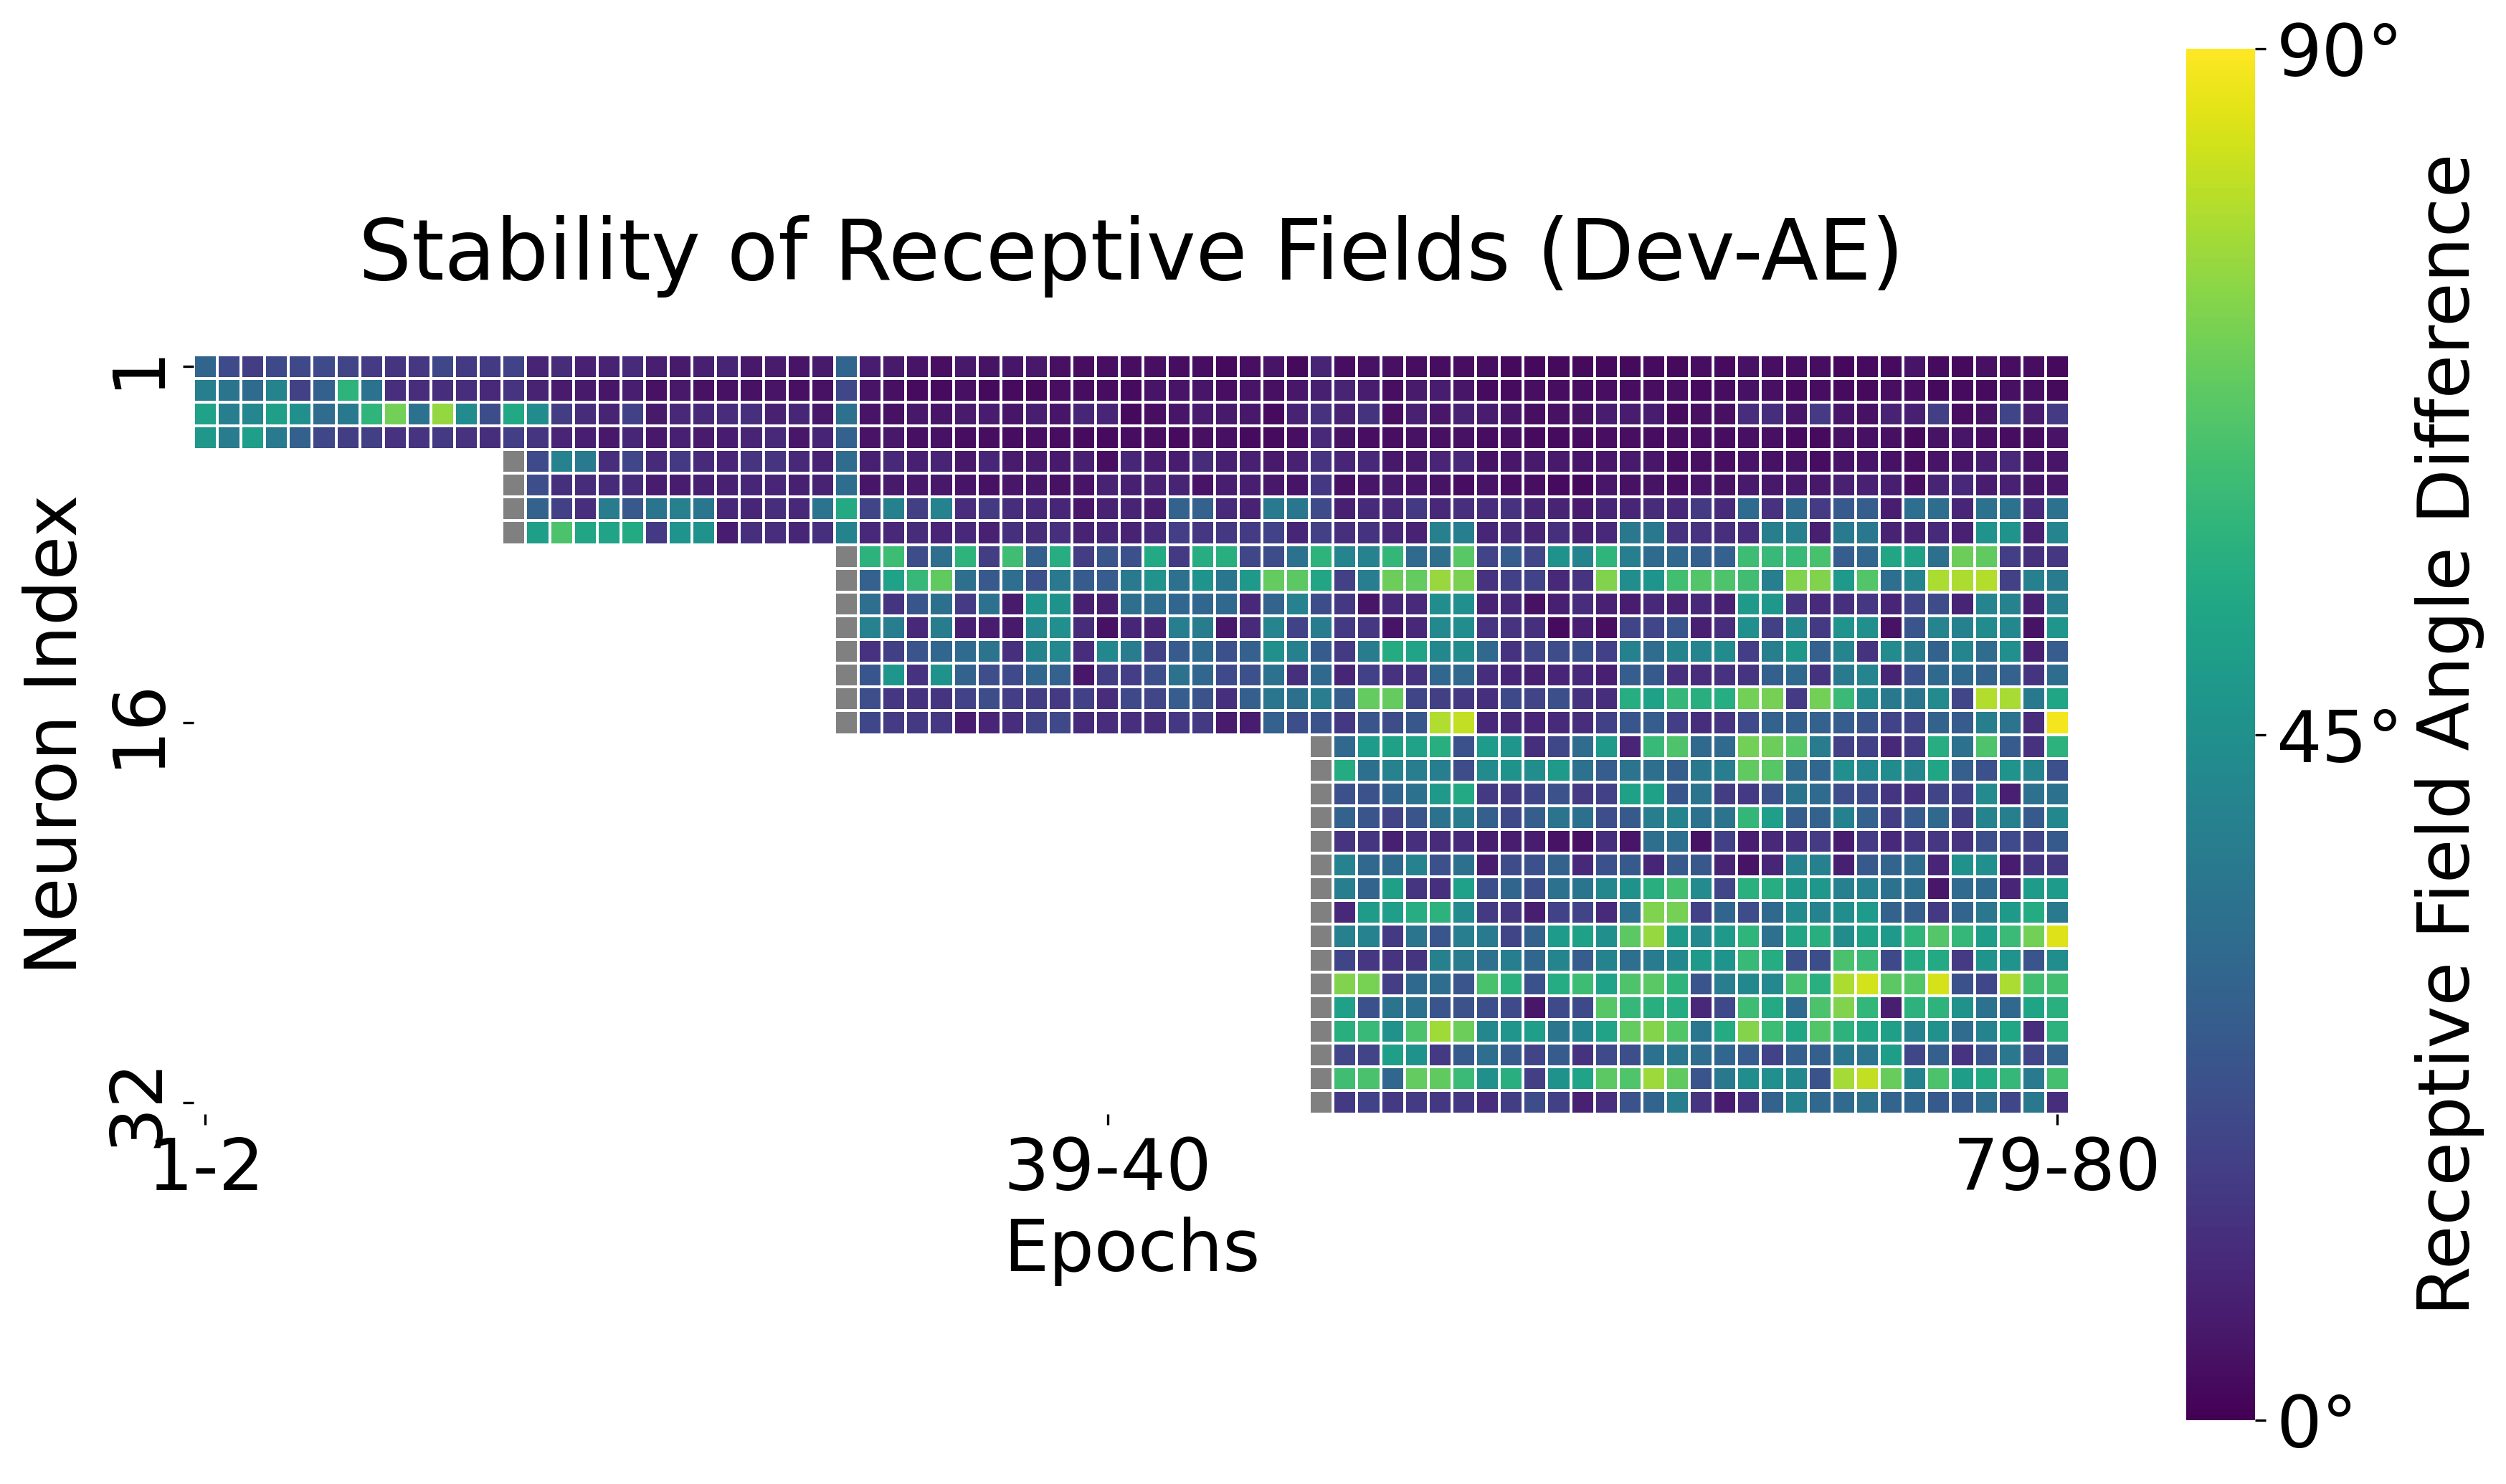

In [36]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

heatmap = sns.heatmap(
    dae_average_angles[:, :],
    cmap="viridis",
    vmin=0,
    vmax=90,
    cbar_kws={"label": "Angle between PCs"},
    linewidths=0.5,
    square=True,
)

cmap_grey = ListedColormap(['grey'])
sns.heatmap(
    non_computable_cells[:, :],
    cmap=cmap_grey,
    cbar=False,
    alpha=1,
    linewidths=0.5,
    square=True,
)

cbar = heatmap.collections[0].colorbar
cbar.set_ticks([0, 45, 90])
cbar.set_ticklabels(["0°", "45°", "90°"], fontsize=24)
cbar.set_label("Receptive Field Angle Difference", fontsize=24)
cbar.minorticks_off()

ax.set_xticks([0.5, 38.5, 78.5])
ax.set_xticklabels(["1-2", "39-40", "79-80"], fontsize=24, rotation=0)

ax.set_yticks([0.5, 15.5, 31.5])
ax.set_yticklabels(["1", "16", "32"], fontsize=24, rotation=90)

ax.set_title("Stability of Receptive Fields (Dev-AE)", fontsize=28, pad=25)
ax.set_xlabel("Epochs", fontsize=24)
ax.set_ylabel("Neuron Index", fontsize=24)

plt.tight_layout()
plt.show()

In [52]:
dae_rf_ls[0].shape

(784,)

/tmp/ipykernel_35135/1318585150.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(f"{model_path}/model_weights_epoch{epoch}.pth")


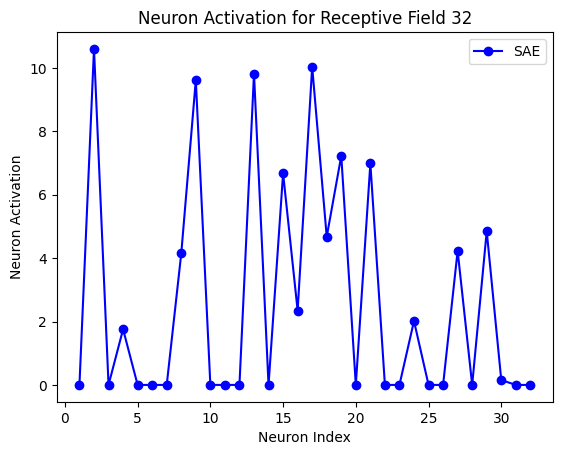

In [58]:
with torch.no_grad():
    dae = load_model(save_path, 'dae', 79)
    
    input = torch.tensor(dae_rf_ls[2]).to('cpu')
    dae_encoded, _ = dae_model[0](input)

    plt.figure()
    plt.plot(range(1, len(dae_encoded)+1), dae_encoded, marker='o', color='blue')
    plt.xlabel('Neuron Index')
    plt.ylabel('Neuron Activation')
    plt.legend(['SAE', 'DAE'])
    plt.title(f'Neuron Activation for Receptive Field {i+1}')
    plt.show()